In [ ]:

from google.colab import drive
drive.mount('/drive')


#data = load('/drive/MyDrive/Start_LLM/eng.train')

Mounted at /drive


In [ ]:
def read_conll_2003(file_path):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Skip CoNLL document boundary markers
            if line.startswith("-DOCSTART-"):
                continue

            if not line:
                # Empty line signifies the end of a sentence
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                # Split columns: word, POS tag, chunk tag, NER tag
                splits = line.split()
                if len(splits) >= 4:
                    word = splits[0]        # Added [0]
                    pos_tag = splits[1]     # Added [1]
                    chunk_tag = splits[2]   # Added [2]
                    ner_tag = splits[3]     # Added [3]
                    current_sentence.append((word, pos_tag, chunk_tag, ner_tag))
        # Append the last sentence if the file doesn't end with an empty line
        if current_sentence:
            sentences.append(current_sentence)

    return sentences

# Load the file from your Colab workspace
file_path = '/drive/MyDrive/Start_LLM/eng.train'
dataset = read_conll_2003(file_path)

# Print out the first sentence to verify the structure
print(f"Total Sentences Loaded: {len(dataset)}")
print("First Sentence Sample:", dataset[0])


Total Sentences Loaded: 14041
First Sentence Sample: [('EU', 'NNP', 'B-NP', 'B-ORG'), ('rejects', 'VBZ', 'B-VP', 'O'), ('German', 'JJ', 'B-NP', 'B-MISC'), ('call', 'NN', 'I-NP', 'O'), ('to', 'TO', 'B-VP', 'O'), ('boycott', 'VB', 'I-VP', 'O'), ('British', 'JJ', 'B-NP', 'B-MISC'), ('lamb', 'NN', 'I-NP', 'O'), ('.', '.', 'O', 'O')]


In [10]:
import pandas as pd

# Flatten the parsed list for tabular representation
flat_data = []
for sentence_id, sentence in enumerate(dataset):
    for word, pos, chunk, ner in sentence:
        flat_data.append([sentence_id, word, pos, chunk, ner])

df = pd.DataFrame(flat_data, columns=['Sentence_ID', 'Word', 'POS', 'Chunk', 'NER_Tag'])
df.head(10)


,Sentence_ID,Word,POS,Chunk,NER_Tag
0,0,EU,NNP,B-NP,B-ORG
1,0,rejects,VBZ,B-VP,O
2,0,German,JJ,B-NP,B-MISC
3,0,call,NN,I-NP,O
4,0,to,TO,B-VP,O
5,0,boycott,VB,I-VP,O
6,0,British,JJ,B-NP,B-MISC
7,0,lamb,NN,I-NP,O
8,0,.,.,O,O
9,1,Peter,NNP,B-NP,B-PER


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203621 entries, 0 to 203620
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Sentence_ID  203621 non-null  int64 
 1   Word         203621 non-null  object
 2   POS          203621 non-null  object
 3   Chunk        203621 non-null  object
 4   NER_Tag      203621 non-null  object
dtypes: int64(1), object(4)
memory usage: 7.8+ MB


In [11]:
# Group the dataframe by Sentence_ID to reconstruct full text sentences
grouped = df.groupby("Sentence_ID").agg({
    "Word": list,
    "NER_Tag": list
}).reset_index()

# Create a human-readable text column just to look at it
grouped["Full_Sentence"] = grouped["Word"].apply(lambda tokens: " ".join(tokens))

# View the first 5 full sentences and their token lists
grouped[["Sentence_ID", "Full_Sentence", "Word", "NER_Tag"]].head(5)


,Sentence_ID,Full_Sentence,Word,NER_Tag
0,0,EU rejects German call to boycott British lamb .,"[EU, rejects, German, call, to, boycott, Briti...","[B-ORG, O, B-MISC, O, O, O, B-MISC, O, O]"
1,1,Peter Blackburn,"[Peter, Blackburn]","[B-PER, I-PER]"
2,2,BRUSSELS 1996-08-22,"[BRUSSELS, 1996-08-22]","[B-LOC, O]"
3,3,The European Commission said on Thursday it di...,"[The, European, Commission, said, on, Thursday...","[O, B-ORG, I-ORG, O, O, O, O, O, O, B-MISC, O,..."
4,4,Germany 's representative to the European Unio...,"[Germany, 's, representative, to, the, Europea...","[B-LOC, O, O, O, O, B-ORG, I-ORG, O, O, O, B-P..."


In [12]:
Dataset = grouped[["Sentence_ID", "Full_Sentence", "Word", "NER_Tag"]]

Dataset.head(10)

,Sentence_ID,Full_Sentence,Word,NER_Tag
0,0,EU rejects German call to boycott British lamb .,"[EU, rejects, German, call, to, boycott, Briti...","[B-ORG, O, B-MISC, O, O, O, B-MISC, O, O]"
1,1,Peter Blackburn,"[Peter, Blackburn]","[B-PER, I-PER]"
2,2,BRUSSELS 1996-08-22,"[BRUSSELS, 1996-08-22]","[B-LOC, O]"
3,3,The European Commission said on Thursday it di...,"[The, European, Commission, said, on, Thursday...","[O, B-ORG, I-ORG, O, O, O, O, O, O, B-MISC, O,..."
4,4,Germany 's representative to the European Unio...,"[Germany, 's, representative, to, the, Europea...","[B-LOC, O, O, O, O, B-ORG, I-ORG, O, O, O, B-P..."
5,5,""" We do n't support any such recommendation be...","["", We, do, n't, support, any, such, recommend...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
6,6,He said further scientific study was required ...,"[He, said, further, scientific, study, was, re...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
7,7,He said a proposal last month by EU Farm Commi...,"[He, said, a, proposal, last, month, by, EU, F...","[O, O, O, O, O, O, O, B-ORG, O, O, B-PER, I-PE..."
8,8,Fischler proposed EU-wide measures after repor...,"[Fischler, proposed, EU-wide, measures, after,...","[B-PER, O, B-MISC, O, O, O, O, B-LOC, O, B-LOC..."
9,9,But Fischler agreed to review his proposal aft...,"[But, Fischler, agreed, to, review, his, propo...","[O, B-PER, O, O, O, O, O, O, O, B-ORG, O, O, O..."


In [15]:
type(Dataset)

pandas.core.frame.DataFrame

In [13]:
Dataset.to_csv(
    "/drive/MyDrive/Start_LLM/Coll_Dataset.csv",

)

In [14]:
Dataset["NER_Tag"].value_counts()

,count
NER_Tag,
"[B-LOC, O]",649
"[B-ORG, O, O, O, O, O, O, O]",400
"[O, B-PER, I-PER, O, B-LOC, O, O]",272
"[O, O]",260
"[B-ORG, I-ORG, O, O, O, O, O, O, O]",254
...,...
"[O, B-LOC, O, O, B-PER, I-PER, I-PER, O, O, O, O, O, O, O, O, O, O, O, B-PER, I-PER, O, O, B-ORG, I-ORG, I-ORG, O, O, O, O, O, O, O, O, O, O, O, O, B-LOC, O]",1
"[O, B-PER, I-PER, O, O, B-PER, O, O, O, O, O, O, O, O, O, O, O, O, B-PER, O]",1
"[O, B-ORG, O, O, O, O, B-PER, I-PER, O, O, O, O, O, O, O, O, O, B-PER, I-PER, O, O, O, O, O, O, O, O, O, B-PER, O, O, O]",1


In [ ]:
Dataset["NER_Tag"].apply(len).max()

113

In [ ]:
class_counts = Dataset["NER_Tag"].value_counts()

class_counts.describe()

,count
count,5684.000000
mean,2.470267
std,14.997636
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,649.000000


In [ ]:
df.groupby("Word")["NER_Tag"].nunique()

temp = df.groupby("Word")["NER_Tag"].unique()
temp[temp > 1]


,NER_Tag
Word,
!,2
"""",1
$,1
%,1
&,2
...,...
zinc,1
zinfandel,1
zlotys,1


In [ ]:
temp = df.groupby("Word")["NER_Tag"].unique()
temp[temp.apply(len) > 1]

,NER_Tag
Word,
!,"[O, I-MISC]"
&,"[I-ORG, I-LOC]"
',"[O, I-ORG, I-MISC]"
'S,"[O, I-ORG]"
's,"[O, I-ORG, I-MISC, I-LOC]"
...,...
the,"[O, I-ORG, I-PER, I-MISC, I-LOC]"
van,"[I-PER, O, B-PER]"
vehicles,"[O, I-ORG]"


In [ ]:
temp.describe()

,NER_Tag
count,23623
unique,1767
top,[O]
freq,15336


In [ ]:
import collections

all_ner_tags = [tag for sublist in Dataset['NER_Tag'] for tag in sublist]


ner_tag_counts = collections.Counter(all_ner_tags)


ner_tag_counts_df = pd.DataFrame(ner_tag_counts.items(), columns=['NER_Tag', 'Count']).sort_values(by='Count', ascending=False)

display(ner_tag_counts_df)

,NER_Tag,Count
1,O,169578
5,B-LOC,7140
3,B-PER,6600
0,B-ORG,6321
4,I-PER,4528
6,I-ORG,3704
2,B-MISC,3438
8,I-LOC,1157
7,I-MISC,1155


In [ ]:
Dataset["text_length"] = Dataset["Full_Sentence"].apply(
    lambda x: len(x.split())
)

Dataset["text_length"].describe()

/tmp/ipykernel_2296/764129126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Dataset["text_length"] = Dataset["Full_Sentence"].apply(


,text_length
count,14041.000000
mean,14.501887
std,11.602756
min,1.000000
25%,6.000000
50%,10.000000
75%,22.000000
max,113.000000


In [ ]:
Dataset["text_length"].quantile([0.90,0.95,0.99])

,text_length
0.90,32.0
0.95,37.0
0.99,46.0


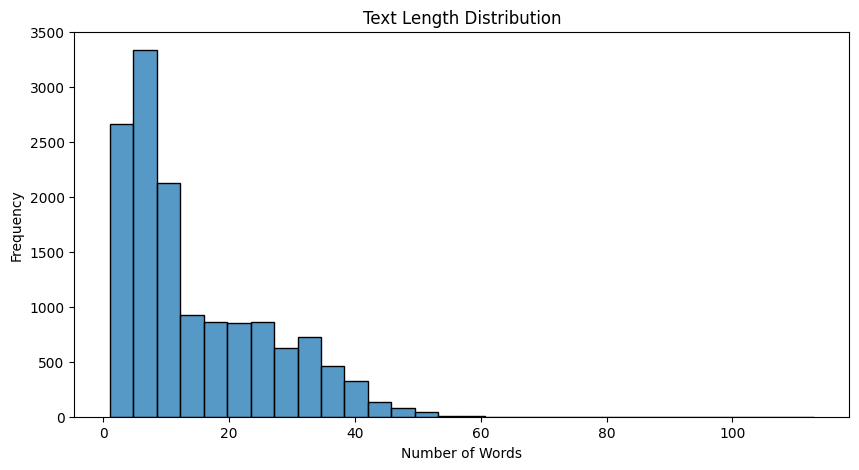

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))

sns.histplot(
    Dataset["text_length"],
    bins=30
)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
import pandas as pd

tag_counts = df['NER_Tag'].value_counts()

tag_percentages = df['NER_Tag'].value_counts(normalize=True) * 100

balance_report = pd.DataFrame({"counts": tag_counts, "percentages": tag_percentages})
print(balance_report)


         counts  percentages
NER_Tag                     
O        169578    83.281194
B-LOC      7140     3.506515
B-PER      6600     3.241316
B-ORG      6321     3.104297
I-PER      4528     2.223739
I-ORG      3704     1.819066
B-MISC     3438     1.688431
I-LOC      1157     0.568213
I-MISC     1155     0.567230


In [ ]:

df['Entity_Type'] = df['NER_Tag'].apply(lambda x: x.split('-')[-1] if '-' in x else x)

entity_counts = df['Entity_Type'].value_counts()
print(entity_counts)


Entity_Type
O       169578
PER      11128
ORG      10025
LOC       8297
MISC      4593
Name: count, dtype: int64


In [ ]:
def check_bio_consistency(dataset_input):
    errors = []


    for sentence_idx, sentence in enumerate(dataset_input):
        previous_tag = "O"


        for token_idx, (word, pos, chunk, current_tag) in enumerate(sentence):


            if current_tag.startswith("I-"):
                current_entity = current_tag.split("-")[1]


                if previous_tag == "O":
                    errors.append({
                        "sentence_id": sentence_idx,
                        "token_id": token_idx,
                        "word": word,
                        "current_tag": current_tag,
                        "previous_tag": previous_tag,
                        "reason": "O tag after I is wrong"
                    })


                elif previous_tag != "O":
                    previous_entity = previous_tag.split("-")[1]
                    if current_entity != previous_entity:
                        errors.append({
                            "sentence_id": sentence_idx,
                            "token_id": token_idx,
                            "word": word,
                            "current_tag": current_tag,
                            "previous_tag": previous_tag,
                            "reason": f"change{previous_entity} to{current_entity}"
                        })


            previous_tag = current_tag

    return errors


bio_errors = check_bio_consistency(dataset)

print(f"number of error {len(bio_errors)}")


if bio_errors:
    import pandas as pd
    errors_df = pd.DataFrame(bio_errors)
    print(errors_df.head(5))
else:
    print("No Error")

number of error 0
No Error


In [ ]:
from collections import Counter
import pandas as pd

def get_entity_span_lengths(dataset):
    span_lengths = []
    current_span_length = 0
    current_entity_type = None

    for sentence in dataset:
        for word, pos, chunk, tag in sentence:
            if tag.startswith("B-"):

                if current_span_length > 0:
                    span_lengths.append((current_entity_type, current_span_length))

                current_entity_type = tag.split("-")[-1]
                current_span_length = 1
            elif tag.startswith("I-"):
                entity_type = tag.split("-")[-1]

                if entity_type == current_entity_type:
                    current_span_length += 1
                else:
                    if current_span_length > 0:
                        span_lengths.append((current_entity_type, current_span_length))
                    current_entity_type = entity_type
                    current_span_length = 1
            else:
                if current_span_length > 0:
                    span_lengths.append((current_entity_type, current_span_length))
                current_span_length = 0
                current_entity_type = None


        if current_span_length > 0:
            span_lengths.append((current_entity_type, current_span_length))
            current_span_length = 0
            current_entity_type = None

    return span_lengths


spans = get_entity_span_lengths(dataset)


spans_df = pd.DataFrame(spans, columns=["Entity_Type", "Span_Length"])


print("--- value count --- ")
print(spans_df["Span_Length"].value_counts(normalize=True) * 100)


print("\n--- average(Entity Type) ---")
print(spans_df.groupby("Entity_Type")["Span_Length"].mean())


print("\n--- max lenght---")
print(spans_df.groupby("Entity_Type")["Span_Length"].max())


--- value count --- 
Span_Length
1     63.113324
2     31.422614
3      3.846972
4      1.063875
5      0.348951
6      0.106388
7      0.076599
10     0.012767
8      0.008511
Name: proportion, dtype: float64

--- average(Entity Type) ---
Entity_Type
LOC     1.162045
MISC    1.335951
ORG     1.585983
PER     1.686061
Name: Span_Length, dtype: float64

--- max lenght---
Entity_Type
LOC     10
MISC     7
ORG     10
PER      6
Name: Span_Length, dtype: int64


In [ ]:
print(ner_tag_counts_df["NER_Tag"])

label_list = []
label_list = ner_tag_counts_df["NER_Tag"]

print(label_list)

1         O
5     B-LOC
3     B-PER
0     B-ORG
4     I-PER
6     I-ORG
2    B-MISC
8     I-LOC
7    I-MISC
Name: NER_Tag, dtype: object
1         O
5     B-LOC
3     B-PER
0     B-ORG
4     I-PER
6     I-ORG
2    B-MISC
8     I-LOC
7    I-MISC
Name: NER_Tag, dtype: object


In [ ]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


#label_list = ["O", "B-ORG", "I-ORG", "B-MISC", "I-MISC"]
label_list = ner_tag_counts_df["NER_Tag"]
label_to_id = {label: i for i, label in enumerate(label_list)}

def tokenize_and_align_labels(examples):
    # این تابع کلمات را از ورودی می‌گیرد (is_split_into_words بسیار مهم است)
    tokenized_inputs = tokenizer(
        examples["Word"],
        truncation=True,
        padding="max_length", # همان پدینگ که گفتی
        max_length=128,
        is_split_into_words=True # به BERT می‌گوید کلمات از قبل جدا شده‌اند
    )

    labels = []
    # گرفتن لیست برچسب‌های متنی جمله
    word_ids = tokenized_inputs.word_ids()
    previous_word_idx = None
    label_ids = []

    for word_idx in word_ids:
        if word_idx is None:
            # برای توکن‌های خاص مثل [CLS] و [PAD] برچسب -100 می‌گذاریم
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            # اگر این توکن، شروع یک کلمه جدید است، برچسب اصلی را به عدد تبدیل می‌کنیم
            text_label = examples["NER_Tag"][word_idx]
            label_ids.append(label_to_id.get(text_label, 0))
        else:
            # اگر کلمه تکه‌تکه شده (Subword)، به تکه‌های بعدی هم -100 می‌دهیم تا مدل گیج نشود
            label_ids.append(-100)
        previous_word_idx = word_idx

    tokenized_inputs["labels"] = label_ids
    return tokenized_inputs

# آزمایش روی اولین جمله جدول برای اینکه خروجی را ببینی:
sample_sentence = {
    "Word": grouped.iloc[0]["Word"],      # کلمات جمله اول از جدول قبلی
    "NER_Tag": grouped.iloc[0]["NER_Tag"] # تگ‌های جمله اول از جدول قبلی
}

output = tokenize_and_align_labels(sample_sentence)

print("کلمات اصلی:", sample_sentence["Word"])
print("توکن‌های عددی BERT (پدینگ شده):", output["input_ids"][:15]) # فقط ۱۵ تای اول برای شلوغ نشدن
print("برچسب‌های عددی تراز شده:", output["labels"][:15])


کلمات اصلی: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
توکن‌های عددی BERT (پدینگ شده): [101, 7270, 22961, 1528, 1840, 1106, 21423, 1418, 2495, 12913, 119, 102, 0, 0, 0]
برچسب‌های عددی تراز شده: [-100, 3, 0, 6, 0, 0, 0, 6, 0, -100, 0, -100, -100, -100, -100]
